# Stagev8.5 result audit

This notebook audits the **freshly rerun Stagev8.5 MMSE-informed ordinal cognitive-severity analysis**.

**Read-only contract:** all cells only load existing CSV, JSON, Markdown, and PNG files under `output/final_report/`. The notebook does not call external APIs, extract E/M/L features, fit models, select hyperparameters, run bootstrap/resampling, or write/overwrite project outputs.

Stagev8.5 is the formal normalized name for the completed Stagev8.4 numerical run. The normalization audit is displayed below and records that no scientific result was recomputed during the version rename.

In [1]:
from __future__ import annotations
from pathlib import Path
import json
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image


def locate_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "run_stagev8.py").exists() and (candidate / "output" / "final_report").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the Stagev8.5 project root. Open the notebook from the project, "
        "or run it with the working directory set to the Stagev8.5 root."
    )

ROOT = locate_project_root()
FINAL = ROOT / "output" / "final_report"
FIGURES = FINAL / "figures"

required = [
    "stagev8_5_final_run_summary.json",
    "stagev8_5_feature_source_audit.json",
    "stagev8_5_mmse_label_contract.json",
    "stagev8_5_external_binary_metrics.csv",
    "stagev8_5_external_ordinal_metrics.csv",
    "stagev8_5_external_threshold_metrics.csv",
    "stagev8_5_external_three_strata_metrics.csv",
    "stagev8_5_external_selective_metrics.csv",
    "stagev8_5_external_severity_scores.csv",
    "stagev8_5_nested_oof_metrics.json",
    "stagev8_5_ordinal_seed_stability.csv",
    "stagev8_5_bootstrap_ci.csv",
]
missing = [name for name in required if not (FINAL / name).exists()]
assert not missing, f"Missing completed Stagev8.5 result artifacts: {missing}"
print(f"Project root: {ROOT}")
print(f"Final-report directory: {FINAL}")
print("Audit mode: read-only; no API/training/extraction/output-writing code is present.")


def load_json(name: str) -> dict:
    return json.loads((FINAL / name).read_text(encoding="utf-8"))


def load_csv(name: str) -> pd.DataFrame:
    return pd.read_csv(FINAL / name)


def percent(x: float) -> str:
    return f"{100*x:.1f}%" if pd.notna(x) else "NA"


Project root: d:\research\H.L.Liang-Lab\Code\expore\stagev8.5
Final-report directory: d:\research\H.L.Liang-Lab\Code\expore\stagev8.5\output\final_report
Audit mode: read-only; no API/training/extraction/output-writing code is present.


## 1. Formal version normalization and feature provenance

In [2]:
summary = load_json("stagev8_5_final_run_summary.json")
source_audit = load_json("stagev8_5_feature_source_audit.json")
labels = load_json("stagev8_5_mmse_label_contract.json")

assert summary.get("feature_extraction_called") is True
assert summary.get("api_called") is True
assert summary.get("feature_counts") == {"E": 61, "M": 1024, "L": 8}

feature_source = summary.get("feature_source", {})
transport = source_audit.get("transport_audit", source_audit.get("transport", {}))

provenance_table = pd.DataFrame([{
    "formal_project": "Stagev8.5",
    "run_type": "clean fresh run from raw CSV",
    "fresh_feature_extraction": summary.get("feature_extraction_called"),
    "fresh_API_calls": summary.get("api_called"),
    "BGE_M3_new_cache_rows": feature_source.get(
        "middle_new_cache_rows",
        source_audit.get("middle_new_cache_rows")
    ),
    "late_LLM_API_scored_samples": feature_source.get(
        "late_api_scored_samples",
        source_audit.get("late_api_scored_samples")
    ),
    "transport_mode": transport.get("transport_mode", "recorded in feature audit"),
    "E_dims": summary["feature_counts"]["E"],
    "M_dims": summary["feature_counts"]["M"],
    "L_dims": summary["feature_counts"]["L"],
}])

display(provenance_table)

print("MMSE contract:")
print(json.dumps(labels, indent=2, ensure_ascii=False))


,formal_project,run_type,fresh_feature_extraction,fresh_API_calls,BGE_M3_new_cache_rows,late_LLM_API_scored_samples,transport_mode,E_dims,M_dims,L_dims
0,Stagev8.5,clean fresh run from raw CSV,True,True,4839,237,curl_schannel_runtime_shim,61,1024,8


MMSE contract:
{
  "status": "pass",
  "label_type": "MMSE-informed ordinal cognitive-severity strata; not clinical early/middle/late staging",
  "thresholds": {
    "high_mmse_AD": "MMSE >= 21",
    "intermediate_mmse_AD": "MMSE 15-20",
    "low_mmse_AD": "MMSE <= 14",
    "T20": "MMSE <= 20 vs >= 21",
    "T14": "MMSE <= 14 vs 15-20, conditional on MMSE <= 20"
  },
  "train_mmse_stratum_counts": {
    "control": 79,
    "high_mmse_AD": 21,
    "intermediate_mmse_AD": 41,
    "low_mmse_AD": 25
  },
  "external_mmse_stratum_counts": {
    "control": 36,
    "high_mmse_AD": 14,
    "intermediate_mmse_AD": 13,
    "low_mmse_AD": 8
  },
  "head_T20_train_counts": {
    "high_mmse_negative": 21,
    "mmse_le_20_positive": 66
  },
  "head_T14_train_counts": {
    "intermediate_mmse_negative": 41,
    "low_mmse_positive": 25
  },
  "external_selection_prohibited": true,
  "rationale": "The 21/15-20/<=14 contract is fixed before Stagev8.5 evaluation and is treated as a sensitivity-motivated M

## 2. Frozen AD/control anchor

In [3]:
binary = load_csv("stagev8_5_external_binary_metrics.csv")
bootstrap = load_csv("stagev8_5_bootstrap_ci.csv")
display(binary)
display(bootstrap[bootstrap["metric"].str.startswith("binary_")].reset_index(drop=True))

row = binary.iloc[0]
print(
    "External anchor: "
    f"accuracy={row['accuracy']:.3f}, balanced_accuracy={row['balanced_accuracy']:.3f}, "
    f"sensitivity={row['sensitivity']:.3f}, specificity={row['specificity']:.3f}, MCC={row['mcc']:.3f}."
)


,accuracy,balanced_accuracy,sensitivity,specificity,precision,f1,mcc,roc_auc,pr_auc,brier,tn,fp,fn,tp
0,0.84507,0.846429,0.942857,0.75,0.785714,0.857143,0.704702,0.855556,0.849592,0.174922,27,9,2,33


,metric,estimate,ci_low,ci_high,bootstrap_n,bootstrap_scheme
0,binary_accuracy,0.845070,0.760563,0.915493,200,stratified_by_true_mmse_stratum
1,binary_balanced_accuracy,0.846429,0.763085,0.916270,200,stratified_by_true_mmse_stratum


External anchor: accuracy=0.845, balanced_accuracy=0.846, sensitivity=0.943, specificity=0.750, MCC=0.705.


## 3. Primary internal evidence: nested OOF ordinal severity

,n,spearman_rho,spearman_p,kendall_tau,kendall_p,pairwise_ordinal_accuracy,n_informative_pairs
0,87,0.331904,0.001686,0.226621,0.002441,0.616582,3534


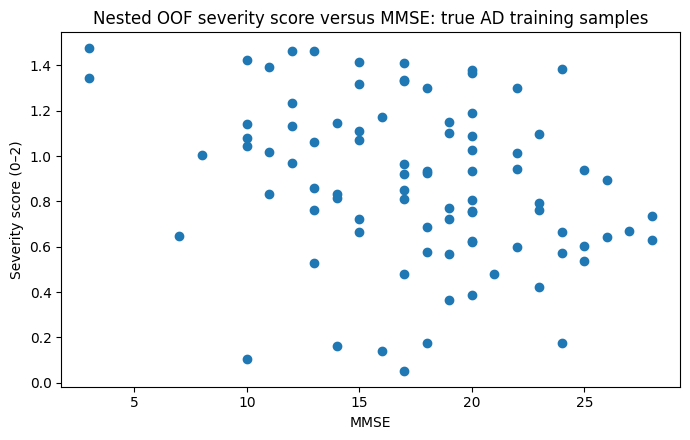

Nested OOF evidence: Spearman rho=0.332 (p=0.001686); Kendall tau=0.227; pairwise ordinal accuracy=0.617.


In [4]:
oof_metrics = load_json("stagev8_5_nested_oof_metrics.json")
oof_ordinal = pd.DataFrame([oof_metrics["ordinal"]])
display(oof_ordinal)

oof_scores = load_csv("stagev8_5_nested_oof_severity_scores.csv")
plt.figure(figsize=(7, 4.5))
plt.scatter(oof_scores["mmse"], oof_scores["severity_score"])
plt.xlabel("MMSE")
plt.ylabel("Severity score (0–2)")
plt.title("Nested OOF severity score versus MMSE: true AD training samples")
plt.tight_layout()
plt.show()

print(
    "Nested OOF evidence: "
    f"Spearman rho={oof_metrics['ordinal']['spearman_rho']:.3f} "
    f"(p={oof_metrics['ordinal']['spearman_p']:.4g}); "
    f"Kendall tau={oof_metrics['ordinal']['kendall_tau']:.3f}; "
    f"pairwise ordinal accuracy={oof_metrics['ordinal']['pairwise_ordinal_accuracy']:.3f}."
)


## 4. Seed stability

In [5]:
head_stability = load_csv("stagev8_5_head_seed_stability.csv")
ordinal_stability = load_csv("stagev8_5_ordinal_seed_stability.csv")

head_summary = (
    head_stability.groupby("head")[["balanced_accuracy", "mcc", "roc_auc", "brier"]]
    .agg(["mean", "std"])
    .round(3)
)
ordinal_summary = (
    ordinal_stability[[
        "spearman_rho", "kendall_tau", "pairwise_ordinal_accuracy", "three_strata_macro_f1"
    ]]
    .agg(["mean", "std"])
    .T
    .round(3)
)
display(head_summary)
display(ordinal_summary)

print(f"Number of fixed-hyperparameter stability seeds: {ordinal_stability['seed'].nunique()}")


balanced_accuracy           mcc        roc_auc         brier       
                  mean    std   mean    std    mean    std   mean    std
head                                                                    
T14              0.524  0.027  0.048  0.052   0.534  0.026  0.259  0.005
T20              0.585  0.043  0.164  0.082   0.698  0.027  0.203  0.007

,mean,std
spearman_rho,0.366,0.037
kendall_tau,0.252,0.028
pairwise_ordinal_accuracy,0.630,0.014
three_strata_macro_f1,0.388,0.030


Number of fixed-hyperparameter stability seeds: 30


## 5. External reference evaluation: ordinal severity and threshold heads

In [6]:
external_ordinal = load_csv("stagev8_5_external_ordinal_metrics.csv")
external_threshold = load_csv("stagev8_5_external_threshold_metrics.csv")
display(external_ordinal)
display(external_threshold)

main_external = external_ordinal.query("scope == 'scope_all_true_AD'").iloc[0]
print(
    "External all-true-AD ordering: "
    f"n={int(main_external['n'])}, rho={main_external['spearman_rho']:.3f} "
    f"(p={main_external['spearman_p']:.4g}), "
    f"tau={main_external['kendall_tau']:.3f}, "
    f"pairwise accuracy={main_external['pairwise_ordinal_accuracy']:.3f}."
)


,scope,n,spearman_rho,spearman_p,kendall_tau,kendall_p,pairwise_ordinal_accuracy,n_informative_pairs
0,scope_all_true_AD,35,0.391948,0.019879,0.280170,0.021302,0.645045,555
1,scope_anchor_admitted_true_AD,33,0.416670,0.015859,0.293234,0.019921,0.652352,489


,scope,accuracy,balanced_accuracy,sensitivity,specificity,precision,f1,mcc,roc_auc,pr_auc,brier,tn,fp,fn,tp
0,T20_all_true_AD,0.714286,0.666667,0.904762,0.428571,0.703704,0.791667,0.388889,0.673469,0.758603,0.213250,6,8,2,19
1,T20_anchor_admitted_true_AD,0.727273,0.680769,0.900000,0.461538,0.720000,0.800000,0.412217,0.696154,0.774354,0.205782,6,7,2,18
2,T14_conditional_all_true_AD,0.571429,0.581731,0.625000,0.538462,0.454545,0.526316,0.158941,0.615385,0.652600,0.244164,7,6,3,5
3,T14_conditional_anchor_admitted_true_AD,0.550000,0.562500,0.625000,0.500000,0.454545,0.526316,0.123091,0.604167,0.657540,0.247413,6,6,3,5


External all-true-AD ordering: n=35, rho=0.392 (p=0.01988), tau=0.280, pairwise accuracy=0.645.


## 6. External severity score, stratum probabilities, and auxiliary three-strata accuracy

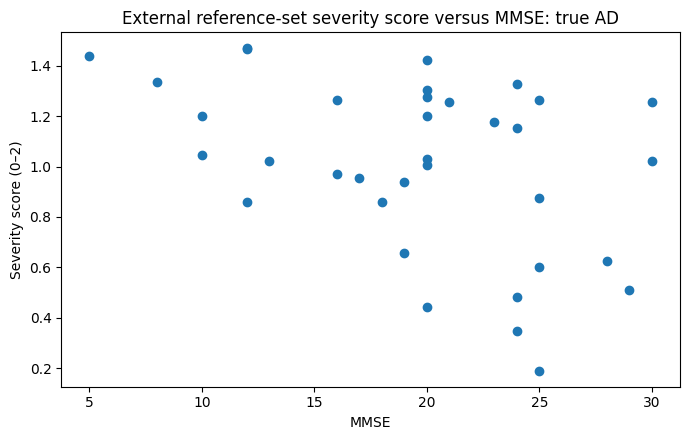

,true_mmse_stratum,count,mean,median,std
0,high_mmse_AD,14,0.863091,0.948049,0.392788
1,intermediate_mmse_AD,13,1.024935,1.005030,0.274113
2,low_mmse_AD,8,1.229835,1.268130,0.234224


,scope,accuracy,macro_f1,weighted_f1,precision_high_mmse_AD,recall_high_mmse_AD,f1_high_mmse_AD,support_high_mmse_AD,precision_intermediate_mmse_AD,recall_intermediate_mmse_AD,f1_intermediate_mmse_AD,support_intermediate_mmse_AD,precision_low_mmse_AD,recall_low_mmse_AD,f1_low_mmse_AD,support_low_mmse_AD,balanced_accuracy
0,conditional_all_true_AD,0.457143,0.454159,0.453421,0.583333,0.500000,0.538462,14,0.400000,0.307692,0.347826,13,0.384615,0.625,0.47619,8,0.477564
1,anchored_all_true_AD,0.428571,0.437063,0.430969,0.583333,0.500000,0.538462,14,0.333333,0.230769,0.272727,13,0.416667,0.625,0.50000,8,0.451923
2,anchor_admitted_true_AD,0.454545,0.448571,0.445714,0.583333,0.538462,0.560000,13,0.333333,0.250000,0.285714,12,0.416667,0.625,0.50000,8,0.471154


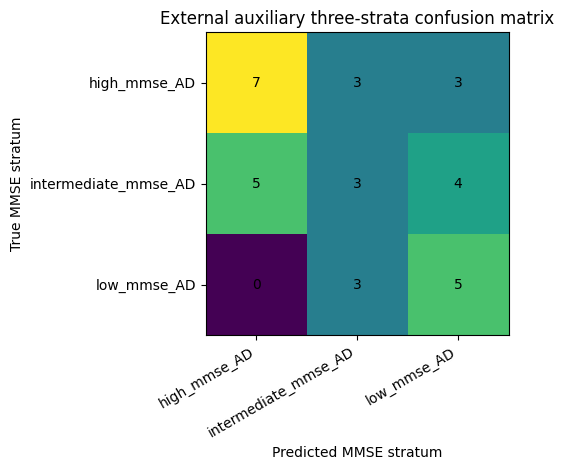

In [7]:
external_scores = load_csv("stagev8_5_external_severity_scores.csv")
external_ad = external_scores[external_scores["__y__"].eq(1)].copy()

plt.figure(figsize=(7, 4.5))
plt.scatter(external_ad["mmse"], external_ad["severity_score"])
plt.xlabel("MMSE")
plt.ylabel("Severity score (0–2)")
plt.title("External reference-set severity score versus MMSE: true AD")
plt.tight_layout()
plt.show()

means = (
    external_ad.groupby("true_mmse_stratum", dropna=False)["severity_score"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)
display(means)

three = load_csv("stagev8_5_external_three_strata_metrics.csv")
confusion_long = load_csv("stagev8_5_confusion_matrix_three_strata.csv")
display(three)

labels_order = ["high_mmse_AD", "intermediate_mmse_AD", "low_mmse_AD"]
confusion = (
    confusion_long.pivot(index="true_mmse_stratum", columns="predicted_mmse_stratum", values="count")
    .reindex(index=labels_order, columns=labels_order, fill_value=0)
)
plt.figure(figsize=(6, 4.8))
plt.imshow(confusion.to_numpy())
plt.xticks(range(len(labels_order)), labels_order, rotation=30, ha="right")
plt.yticks(range(len(labels_order)), labels_order)
plt.xlabel("Predicted MMSE stratum")
plt.ylabel("True MMSE stratum")
plt.title("External auxiliary three-strata confusion matrix")
for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(j, i, int(confusion.iloc[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()


## 7. Selective reporting and uncertainty

,accuracy,macro_f1,weighted_f1,precision_high_mmse_AD,recall_high_mmse_AD,f1_high_mmse_AD,support_high_mmse_AD,precision_intermediate_mmse_AD,recall_intermediate_mmse_AD,f1_intermediate_mmse_AD,support_intermediate_mmse_AD,precision_low_mmse_AD,recall_low_mmse_AD,f1_low_mmse_AD,support_low_mmse_AD,balanced_accuracy,n_true_AD_anchor_admitted,n_reported,coverage,abstention_rate
0,0.6,0.472222,0.577778,0.75,0.75,0.75,8,0.0,0.0,0.0,3,0.6,0.75,0.666667,4,0.5,33,15,0.454545,0.545455


,true_mmse_stratum,n_anchor_admitted,n_reported,coverage,abstention_rate
0,high_mmse_AD,13,8,0.615385,0.384615
1,intermediate_mmse_AD,12,3,0.250000,0.750000
2,low_mmse_AD,8,4,0.500000,0.500000


Selective coverage=45.5%; reported n=15/33; selective macro-F1=0.472.


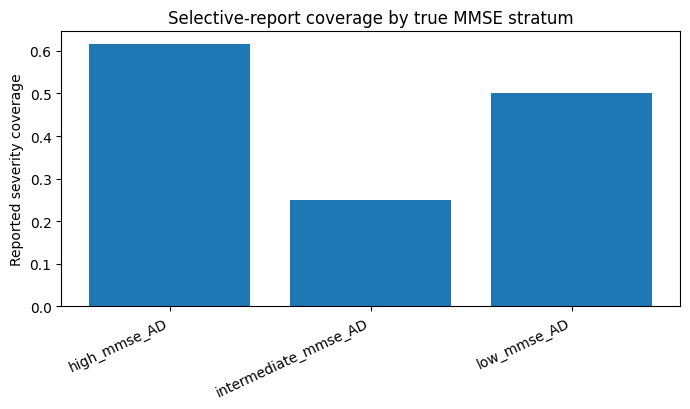

In [8]:
selective = load_csv("stagev8_5_external_selective_metrics.csv")
abstention = load_csv("stagev8_5_external_abstention_by_stratum.csv")
display(selective)
display(abstention)

sel = selective.iloc[0]
print(
    f"Selective coverage={percent(sel['coverage'])}; "
    f"reported n={int(sel['n_reported'])}/{int(sel['n_true_AD_anchor_admitted'])}; "
    f"selective macro-F1={sel['macro_f1']:.3f}."
)

plt.figure(figsize=(7, 4.2))
plt.bar(abstention["true_mmse_stratum"], abstention["coverage"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Reported severity coverage")
plt.title("Selective-report coverage by true MMSE stratum")
plt.tight_layout()
plt.show()


## 8. Bootstrap uncertainty and saved figures

,metric,estimate,ci_low,ci_high,bootstrap_n,bootstrap_scheme
0,binary_accuracy,0.845070,0.760563,0.915493,200,stratified_by_true_mmse_stratum
1,binary_balanced_accuracy,0.846429,0.763085,0.916270,200,stratified_by_true_mmse_stratum
2,severity_spearman_rho,0.391948,0.097304,0.631300,200,stratified_by_true_mmse_stratum
3,severity_kendall_tau,0.280170,0.092223,0.475271,200,stratified_by_true_mmse_stratum
4,severity_pairwise_ordinal_accuracy,0.645045,0.547441,0.745478,200,stratified_by_true_mmse_stratum
5,T20_balanced_accuracy,0.666667,0.535417,0.797917,200,stratified_by_true_mmse_stratum
6,T14_balanced_accuracy,0.581731,0.378846,0.783654,200,stratified_by_true_mmse_stratum
7,three_strata_macro_f1_anchor_admitted,0.448571,0.288866,0.626715,200,stratified_by_true_mmse_stratum
8,selective_coverage_anchor_admitted,0.454545,0.280836,0.613022,200,stratified_by_true_mmse_stratum


**fig01_nested_oof_severity_vs_mmse.png**

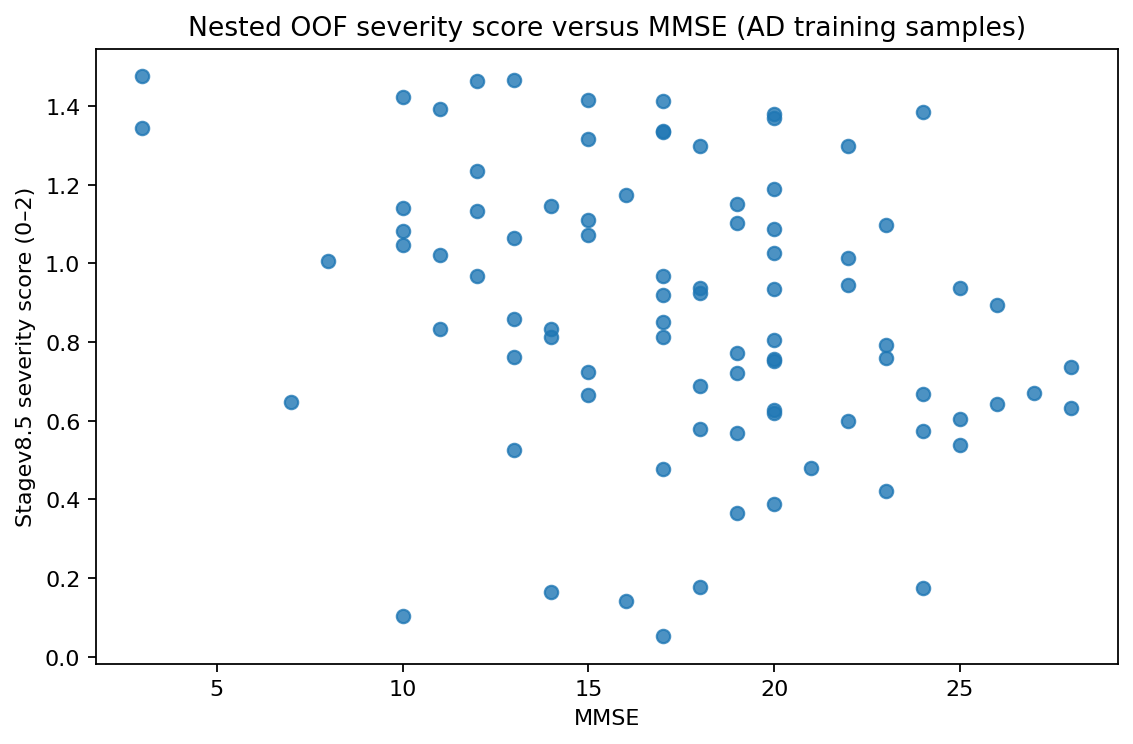

**fig02_external_severity_vs_mmse.png**

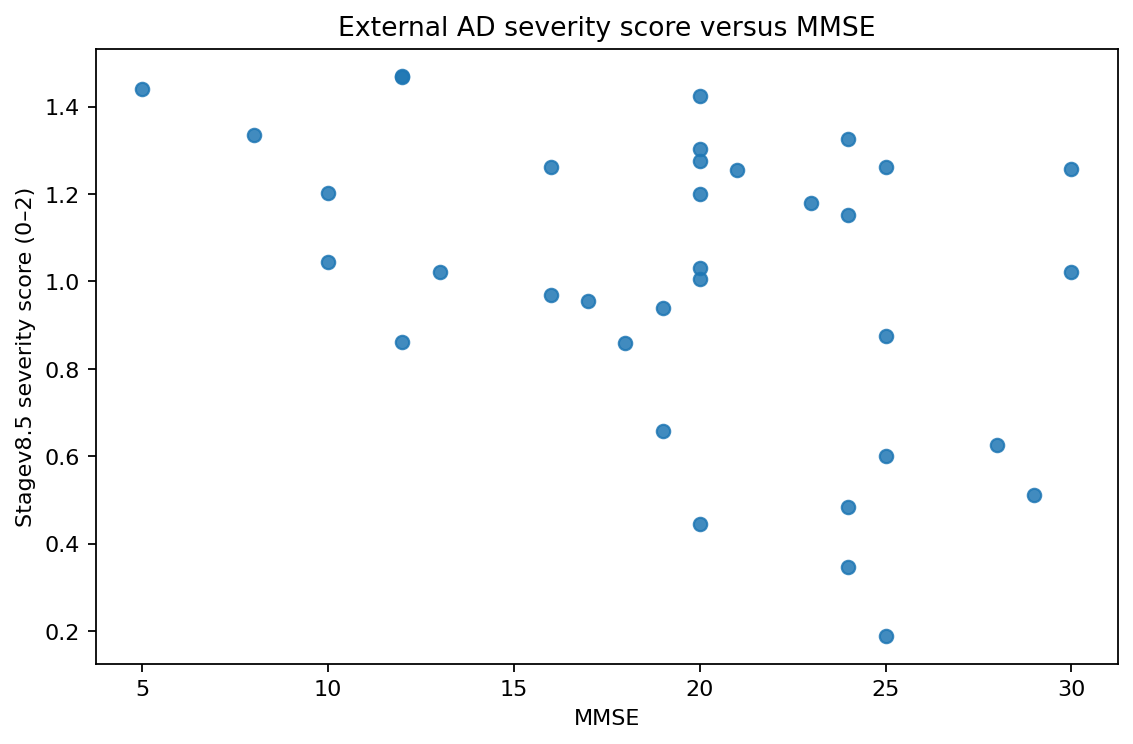

**fig03_external_stratum_probability_distribution.png**

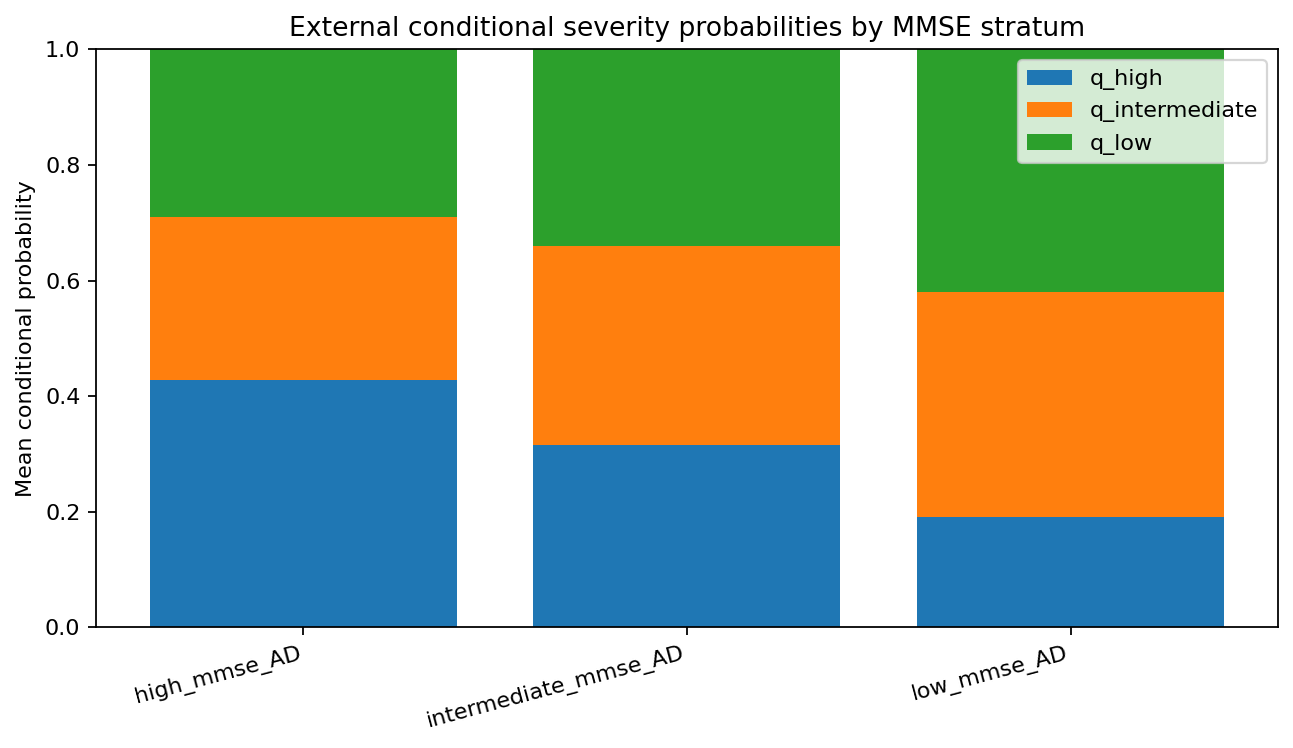

**fig04_threshold_calibration.png**

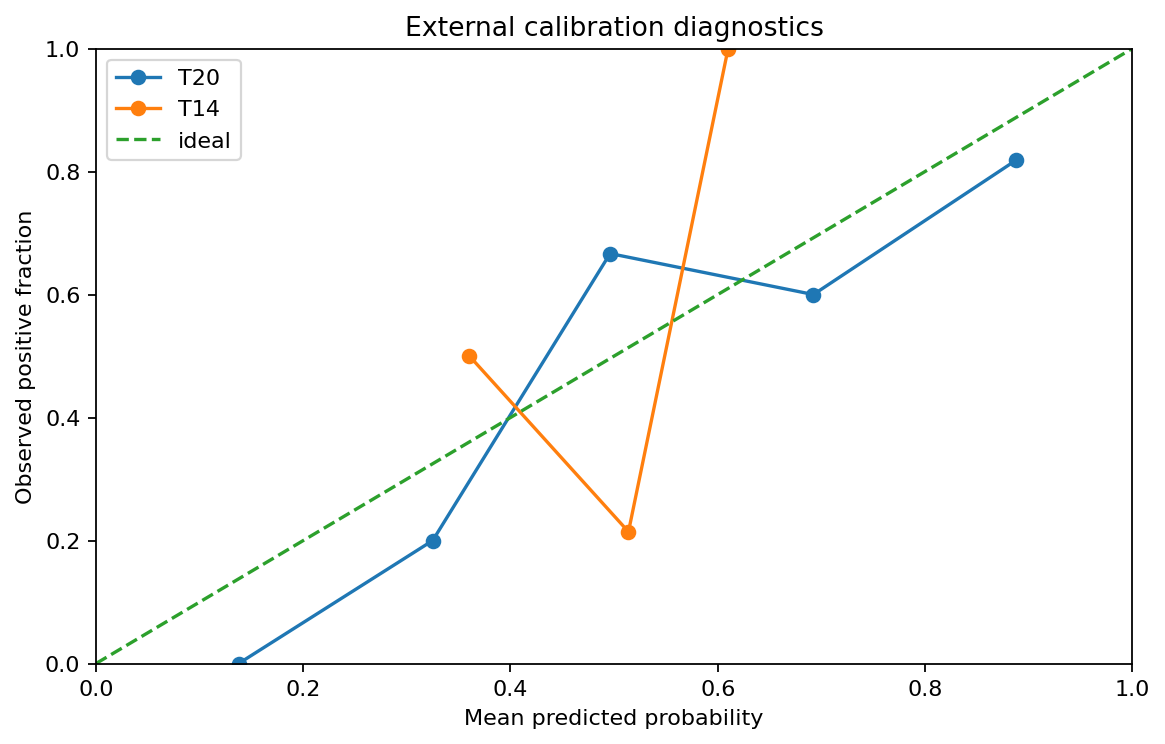

**fig05_selective_coverage_by_stratum.png**

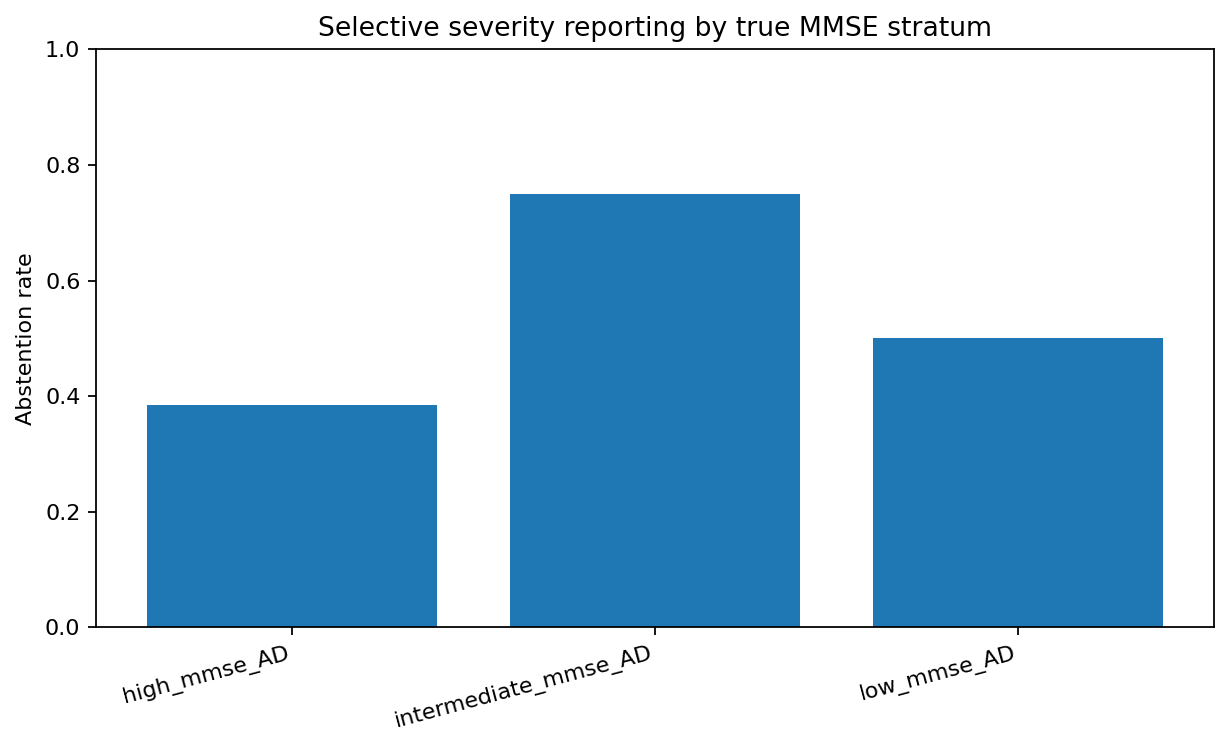

**fig06_bootstrap_ci.png**

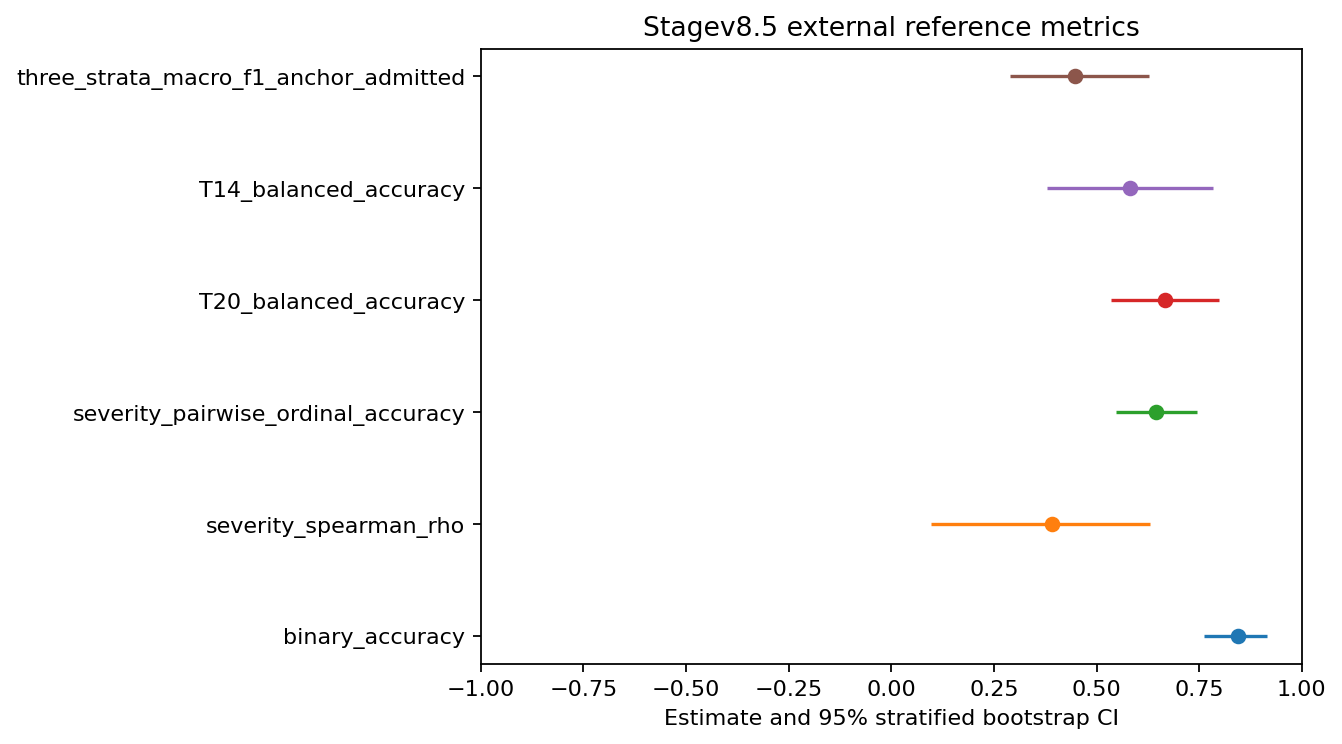

In [9]:
display(bootstrap)

for filename in [
    "fig01_nested_oof_severity_vs_mmse.png",
    "fig02_external_severity_vs_mmse.png",
    "fig03_external_stratum_probability_distribution.png",
    "fig04_threshold_calibration.png",
    "fig05_selective_coverage_by_stratum.png",
    "fig06_bootstrap_ci.png",
]:
    path = FIGURES / filename
    if path.exists():
        display(Markdown(f"**{filename}**"))
        display(Image(filename=str(path)))


## 9. Audit conclusion generated from the saved metrics

In [10]:
oof = oof_metrics["ordinal"]
ext = main_external
sel = selective.iloc[0]

conclusion = f"""
### Result-boundary summary

- **Disease decision:** the frozen Stagev5 anchor retained external balanced accuracy **{binary.iloc[0]['balanced_accuracy']:.3f}**.
- **Primary internal severity evidence:** nested OOF Spearman rho was **{oof['spearman_rho']:.3f}** (p={oof['spearman_p']:.4g}) and pairwise ordinal accuracy was **{oof['pairwise_ordinal_accuracy']:.3f}**.
- **External severity evidence:** the all-true-AD reference evaluation had Spearman rho **{ext['spearman_rho']:.3f}** (p={ext['spearman_p']:.4g}) and pairwise ordinal accuracy **{ext['pairwise_ordinal_accuracy']:.3f}**.
- **Selective reporting:** coverage was **{sel['coverage']:.3f}** with selective macro-F1 **{sel['macro_f1']:.3f}**.

The saved results support an MMSE-informed **ordinal cognitive-severity tendency** with uncertainty-aware reporting. They do not establish reliable individual-level clinical early/middle/late dementia staging. External results are reference evaluation only and were not used to choose the model, thresholds, or MMSE boundaries.
"""
display(Markdown(conclusion))



### Result-boundary summary

- **Disease decision:** the frozen Stagev5 anchor retained external balanced accuracy **0.846**.
- **Primary internal severity evidence:** nested OOF Spearman rho was **0.332** (p=0.001686) and pairwise ordinal accuracy was **0.617**.
- **External severity evidence:** the all-true-AD reference evaluation had Spearman rho **0.392** (p=0.01988) and pairwise ordinal accuracy **0.645**.
- **Selective reporting:** coverage was **0.455** with selective macro-F1 **0.472**.

The saved results support an MMSE-informed **ordinal cognitive-severity tendency** with uncertainty-aware reporting. They do not establish reliable individual-level clinical early/middle/late dementia staging. External results are reference evaluation only and were not used to choose the model, thresholds, or MMSE boundaries.
